[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\piriyadharshini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Accuracy: 0.968609865470852
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



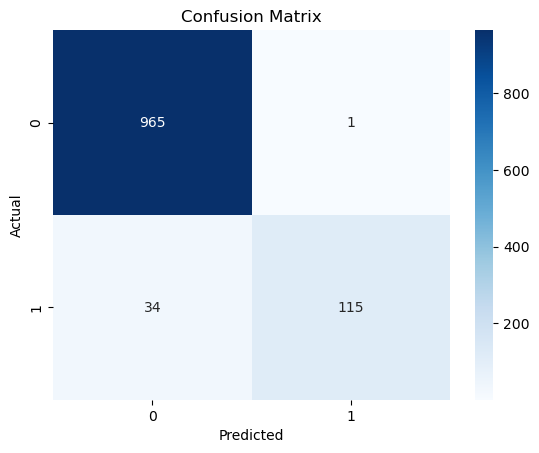

      Label                                            Message  \
3057      1  You are now unsubscribed all services. Get ton...   
5         1  FreeMsg Hey there darling it's been 3 week's n...   
1021      1  Guess what! Somebody you know secretly fancies...   
3748      1  Dear Voucher Holder 2 claim your 1st class air...   
855       1  Talk sexy!! Make new friends or fall in love i...   

                                                Cleaned  
3057  unsubscribed services get tons sexy babes hunk...  
5     freemsg hey darling weeks word back id like fu...  
1021  guess somebody know secretly fancies wanna fin...  
3748  dear voucher holder claim st class airport lou...  
855   talk sexy make new friends fall love worlds di...  
Top Spam Words:
call
free
txt
claim
mobile
ur
stop
text
prize
reply
urgent
service
cash
new
nokia


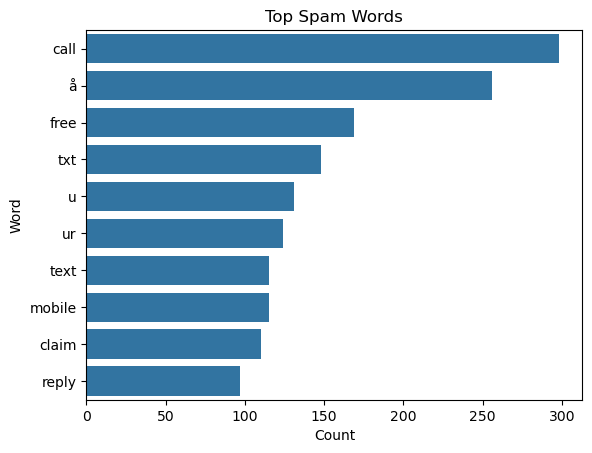

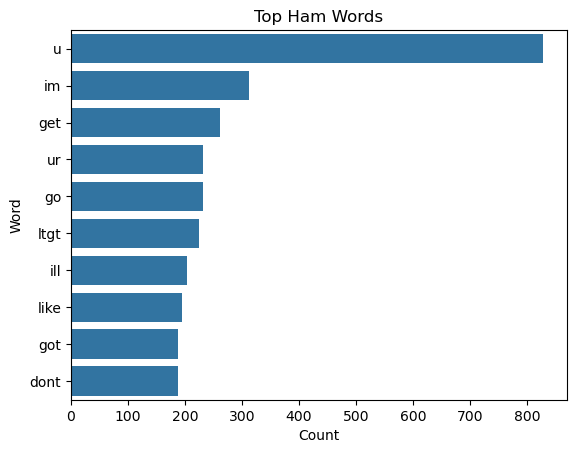

In [4]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download("stopwords")

# Load data
df = pd.read_csv(
    "spam.csv",
    encoding="latin-1",
    usecols=[0, 1],
    names=["Label", "Message"],
    header=0
)

# Clean text
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

df["Cleaned"] = df["Message"].apply(clean_text)

# Encode labels
df["Label"] = df["Label"].map({"ham": 0, "spam": 1})

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["Cleaned"])
y = df["Label"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Misclassified samples
misclassified = df.iloc[y_test.index][y_test != y_pred]
print(misclassified.head())

# Top spam words
feature_names = vectorizer.get_feature_names_out()

spam_probs = model.feature_log_prob_[1]
top_spam = np.argsort(spam_probs)[-15:]

print("Top Spam Words:")
for i in reversed(top_spam):
    print(feature_names[i])

from collections import Counter

# Separate spam and ham
spam_text = df[df["Label"] == 1]["Cleaned"].str.cat()
ham_text = df[df["Label"] == 0]["Cleaned"].str.cat()

# Count words
spam_count = Counter(spam_text.split()).most_common(10)
ham_count = Counter(ham_text.split()).most_common(10)

spam_df = pd.DataFrame(spam_count, columns=["Word", "Count"])
ham_df = pd.DataFrame(ham_count, columns=["Word", "Count"])

# Plot spam words
plt.figure()
sns.barplot(x="Count", y="Word", data=spam_df)
plt.title("Top Spam Words")
plt.show()

# Plot ham words
plt.figure()
sns.barplot(x="Count", y="Word", data=ham_df)
plt.title("Top Ham Words")
plt.show()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  
Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



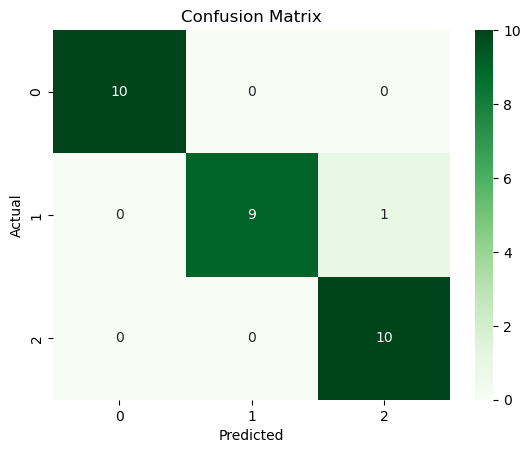

First 5 Probability Predictions:
[[1.00000000e+000 2.10423321e-020 1.24046582e-025]
 [8.47864773e-143 8.77457739e-002 9.12254226e-001]
 [2.60594077e-036 9.99999490e-001 5.10180421e-007]
 [1.34650033e-036 9.99999567e-001 4.32500771e-007]
 [1.00000000e+000 6.60691144e-021 6.79223535e-026]]

Logistic Regression Accuracy: 0.9333333333333333


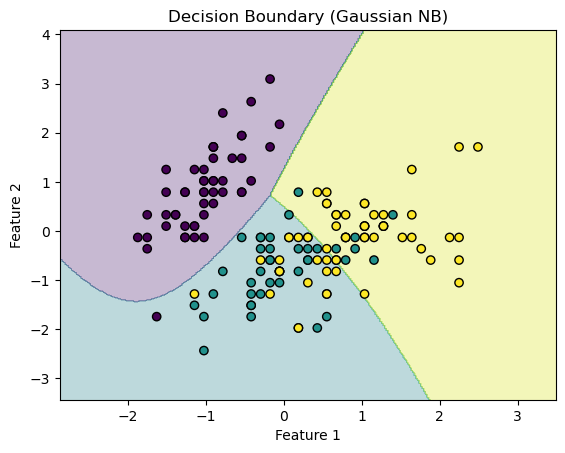

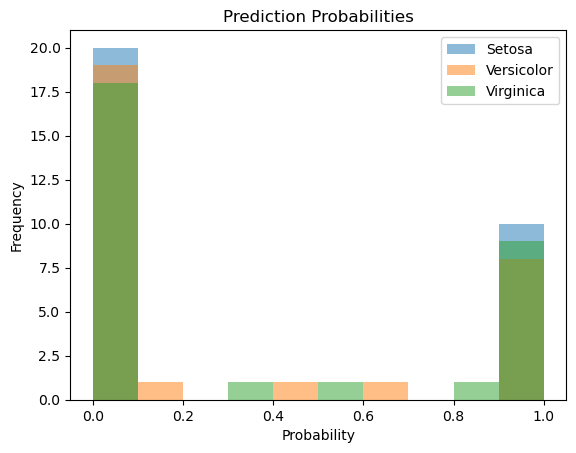

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = y

print(df.head())

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Train Gaussian NB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict
y_pred = gnb.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Class probabilities
probs = gnb.predict_proba(X_test)

print("First 5 Probability Predictions:")
print(probs[:5])

# Logistic Regression (comparison)
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

# Use only first two features
X2 = X_scaled[:, :2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

gnb2 = GaussianNB()
gnb2.fit(X_train2, y_train2)

# Mesh grid
x_min, x_max = X2[:, 0].min()-1, X2[:, 0].max()+1
y_min, y_max = X2[:, 1].min()-1, X2[:, 1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = gnb2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:,0], X2[:,1], c=y, edgecolor="k")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary (Gaussian NB)")
plt.show()

plt.figure()
plt.hist(probs[:,0], alpha=0.5, label="Setosa")
plt.hist(probs[:,1], alpha=0.5, label="Versicolor")
plt.hist(probs[:,2], alpha=0.5, label="Virginica")

plt.legend()
plt.title("Prediction Probabilities")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()